In [1]:
!pip install missingno
!pip install xgboost lightgbm scikit-learn

In [2]:
import os
import pandas as pd
import numpy as np
import warnings
import gc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/kurt54/43temp/data_43_temp.csv", skiprows=[1,2]) #trước mắt bỏ 2 dòng đầu cho dễ xử lí
print(f"temp_dataset: {df.shape}")

temp_dataset: (17526, 44)


---
# **Create Missing Data**

In [4]:
def generate_fixed_length_gaps(df_input, gap_days, num_gaps=10, seed=42, rows_per_day=8):
    """
    Tạo bộ dữ liệu missing với CÙNG MỘT độ dài gap cho tất cả các vị trí được chọn.
    Có tích hợp thuật toán chống đè (anti-overlap) để đảm bảo các gap không dính vào nhau.
    """
    df_temp = df_input.copy(deep=True)
    feature_columns = [col for col in df_temp.columns if col != "TimeVN"]
    
    # Đảm bảo format datetime để tìm đúng 1:00 AM
    ts = pd.to_datetime(df_temp['TimeVN'], format='mixed', dayfirst=True, errors='coerce')
    
    # Lấy ra vị trí (integer index) của các dòng có giờ = 1
    # Dùng np.where để lấy vị trí tuyệt đối, an toàn hơn loc khi thao tác
    daily_start_positions = np.where(ts.dt.hour == 1)[0].tolist()
    
    np.random.seed(seed)
    gap_rows = gap_days * rows_per_day
    
    # Dictionary lưu lại các index bị xóa để sau này tính RMSE, MAE
    missing_ground_truth = {col: [] for col in feature_columns}

    for col in feature_columns:
        col_idx = df_temp.columns.get_loc(col)
        
        # Chỉ giữ lại các vị trí bắt đầu mà khi cộng thêm gap_rows không vượt quá chiều dài data
        valid_starts = [pos for pos in daily_start_positions if pos + gap_rows <= len(df_temp)]
        
        available_starts = valid_starts.copy()
        
        for _ in range(num_gaps):
            if not available_starts:
                print(f"Cảnh báo: Không đủ khoảng trống để tạo đủ {num_gaps} gaps cho cột {col}")
                break
                
            # Chọn ngẫu nhiên 1 vị trí bắt đầu
            start_pos = np.random.choice(available_starts)
            end_pos = start_pos + gap_rows
            
            # Xóa dữ liệu (gán NaN)
            df_temp.iloc[start_pos:end_pos, col_idx] = np.nan
            
            # Lưu lại vị trí đã đục lỗ
            missing_ground_truth[col].extend(list(range(start_pos, end_pos)))
            
            # --- CƠ CHẾ CHỐNG ĐÈ (ANTI-OVERLAP) ---
            # Xóa bỏ các vị trí bắt đầu (start_pos) lân cận ra khỏi danh sách available_starts
            # Khoảng cách tối thiểu giữa 2 điểm bắt đầu phải lớn hơn chiều dài của gap
            available_starts = [pos for pos in available_starts if abs(pos - start_pos) > gap_rows]

    return df_temp, missing_ground_truth

# ================= TẠO 4 BỘ DATASET ĐỘC LẬP =================

# Giả sử 'df' là dataframe gốc của bạn
gap_scenarios = [1, 3, 5, 7]
missing_datasets = {}       # Chứa 4 dataframe đã bị đục lỗ
ground_truth_indices = {}   # Chứa vị trí các lỗ hổng để tính sai số sau này

for days in gap_scenarios:
    print(f"Đang tạo dataset cho kịch bản missing {days} ngày liên tục...")
    
    # Gọi hàm cho từng độ dài
    df_miss, truth_dict = generate_fixed_length_gaps(
        df_input=df, 
        gap_days=days, 
        num_gaps=10,   # Tùy chỉnh số lượng đoạn đứt gãy bạn muốn tạo
        seed=42,       # Giữ nguyên seed để kết quả random có thể tái lập được
        rows_per_day=8
    )
    
    # Lưu vào dictionary
    missing_datasets[f'gap_{days}d'] = df_miss
    ground_truth_indices[f'gap_{days}d'] = truth_dict
    
    total_nan = df_miss.isna().sum().sum()
    print(f"-> Hoàn tất! Tổng số NaN tạo ra: {total_nan}\n")

Đang tạo dataset cho kịch bản missing 1 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 3440

Đang tạo dataset cho kịch bản missing 3 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 10320

Đang tạo dataset cho kịch bản missing 5 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 17200

Đang tạo dataset cho kịch bản missing 7 ngày liên tục...
-> Hoàn tất! Tổng số NaN tạo ra: 24080



In [5]:
# import missingno as msno
# msno.matrix(missing_datasets['gap_1d'])

In [6]:
import pandas as pd
import numpy as np
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

def split_by_hierarchical_stats(df, k=0.75, time_col='TimeVN'):
    """
    Chia nhóm dựa trên Mean và Std của Global Scores.
    k: Hệ số điều chỉnh độ rộng của nhóm Medium.
    """
    # Tách dữ liệu số
    df_numeric = df.select_dtypes(include=[np.number])
    
    # 1. Ensemble Correlation (Pearson + Spearman)
    corr_p = df_numeric.corr(method='pearson').abs()
    corr_s = df_numeric.corr(method='spearman').abs()
    corr = (corr_p + corr_s) / 2
    
    # 2. Tính Global Scores (Stability-adjusted Centrality)
    # Mean của từng hàng (bỏ tự tương quan đường chéo)
    mean_corr = corr.apply(lambda row: row.drop(row.name).mean(), axis=1)
    # Std của từng hàng (độ bất ổn định của tương quan)
    std_corr = corr.apply(lambda row: row.drop(row.name).std(), axis=1)
    
    # Global score: Ưu tiên tương quan cao và ổn định (std thấp)
    global_scores = mean_corr - (1.0 * std_corr) 

    # 3. TỰ ĐỘNG TÍNH NGƯỠNG THEO MEAN & STD
    mu = global_scores.mean()
    sigma = global_scores.std()
    
    low_thresh = mu - k * sigma
    high_thresh = mu + k * sigma
    
    # 4. Phân tách cột
    low_cols = global_scores[global_scores < low_thresh].index.tolist()
    high_cols = global_scores[global_scores >= high_thresh].index.tolist()
    med_cols = global_scores[(global_scores >= low_thresh) & (global_scores < high_thresh)].index.tolist()
    
    # 5. Distance Matrix & Linkage (Phục vụ vẽ Dendrogram nếu cần)
    dist_matrix = 1 - corr.fillna(0)
    dist_vec = squareform(dist_matrix, checks=False)
    linkage_matrix = hierarchy.ward(dist_vec)
    
    # Trả kết quả
    time_list = [time_col] if time_col in df.columns else []
    return (df[time_list + low_cols], 
            df[time_list + med_cols], 
            df[time_list + high_cols], 
            global_scores, low_thresh, high_thresh)

def plot_correlation_split_v2(global_scores, low_thresh, high_thresh):
    scores_sorted = global_scores.sort_values()
    features = scores_sorted.index
    values = scores_sorted.values
    mu = global_scores.mean()

    # Màu sắc cho 3 nhóm
    colors = ['#87CEFA' if v < low_thresh else '#FF6347' if v >= high_thresh else '#FFB6C1' for v in values]

    plt.figure(figsize=(13, 6))
    bars = plt.bar(features, values, color=colors, edgecolor='black', alpha=0.7)

    # Vẽ đường Threshold và Mean
    plt.axhline(y=low_thresh, color='blue', linestyle='--', label=f'Low Thresh (μ - kσ): {low_thresh:.3f}')
    plt.axhline(y=high_thresh, color='red', linestyle='--', label=f'High Thresh (μ + kσ): {high_thresh:.3f}')
    plt.axhline(y=mu, color='green', linestyle='-', alpha=0.5, label=f'Mean (μ): {mu:.3f}')

    plt.title('Feature Classification by Statistical Thresholds', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Thêm text số lượng vào biểu đồ
    low_n = (values < low_thresh).sum()
    med_n = ((values >= low_thresh) & (values < high_thresh)).sum()
    high_n = (values >= high_thresh).sum()
    
    plt.text(len(values), low_thresh, f' n={low_n}', color='blue', fontweight='bold')
    plt.text(len(values), high_thresh, f' n={high_n}', color='red', fontweight='bold')

    plt.tight_layout()
    plt.show()

--- Thống kê phân bổ ---
Low (dưới 0.507): 9 features
Medium: 23 features
High (trên 0.637): 11 features


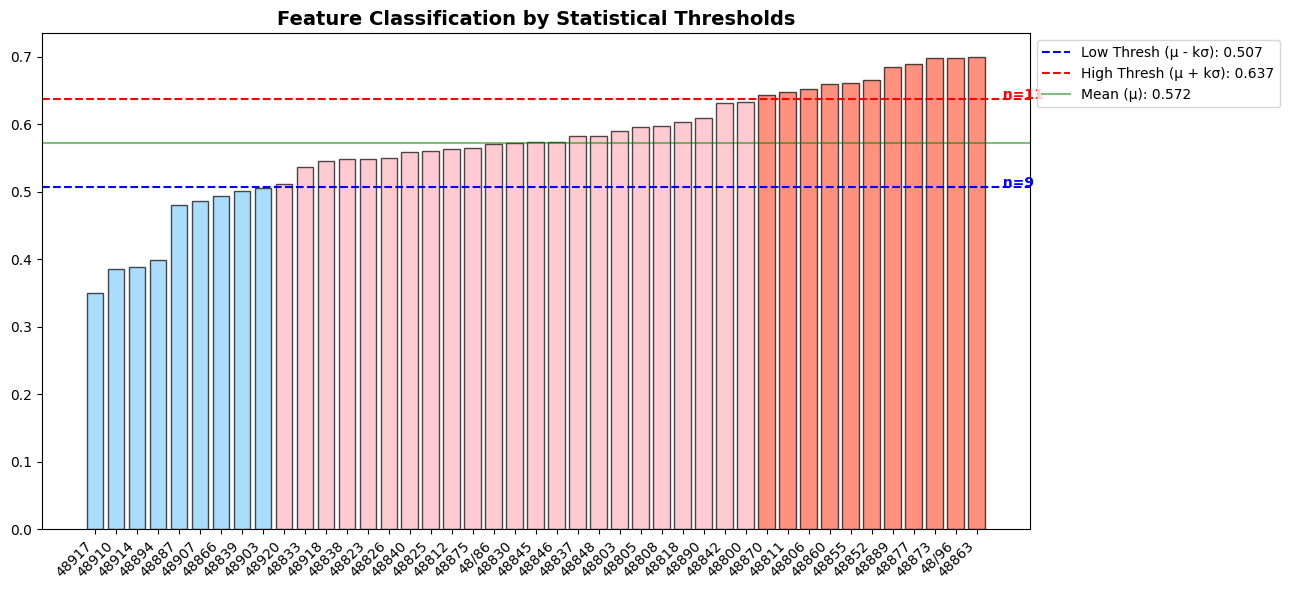

In [7]:
# k=0.75 là mức chia khá cân bằng. 
# Nếu muốn nhóm Medium hẹp lại (ít biến hơn), hãy giảm k xuống (vớ dụ k=0.5).
df_low, df_med, df_high, scores, lt, ht = split_by_hierarchical_stats(df, k=0.75)

print(f"--- Thống kê phân bổ ---")
print(f"Low (dưới {lt:.3f}): {len(df_low.columns) - 1} features")
print(f"Medium: {len(df_med.columns) - 1} features")
print(f"High (trên {ht:.3f}): {len(df_high.columns) - 1} features")

plot_correlation_split_v2(scores, lt, ht)

---
# **Models**

In [8]:
pip install pypots

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.8/779.8 kB 38.4 MB/s eta 0:00:00
  Created wheel for progressbar: filename=progressbar-2.5-py3-none-any.whl size=12065 sha256=42557a47f0de0a99f1fe563ba88d8c71195b781434e0cb442b6cf128000dc7c6
  Stored in directory: /root/.cache/pip/wheels/a5/4d/c7/f3cf0f75c746c219090060131fe00f1523cc2c5484991f4030
Successfully built progressbar
Note: you may need to restart the kernel to use updated packages.


In [9]:
import time
import pandas as pd
import numpy as np
import gc
import os
import torch
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.base import clone as sk_clone  # Đã thêm thư viện sk_clone
from lightgbm import LGBMRegressor
from pypots.imputation import SAITS
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# SEED 1: WEIGHTED LGBM — đã fix data leakage
# ==========================================
def get_weighted_lgbm_seed(df_miss):
    """
    Fix: X_train/X_test chỉ dùng các cột KHÁC (không phải cột đang predict),
    lấy từ df_features (linear interp của cột khác — không phải cột target).
    Điều này loại bỏ việc LGBM học "hình dáng linear" của chính cột đó.
    n_estimators tăng lên 50 để học pattern tốt hơn.
    """
    df_num      = df_miss.select_dtypes(include=[np.number]).copy().astype('float32')
    df_features = (df_num.interpolate(method='linear', limit_direction='both')
                         .ffill().bfill().fillna(0))
    df_filled   = df_num.copy()
    target_cols = df_num.columns.tolist()

    for col in target_cols:
        s = df_num[col].reset_index(drop=True)
        if not s.isna().any():
            continue

        # Chỉ dùng cột KHÁC làm feature — không dùng linear interp của chính col
        features = [c for c in target_cols if c != col]
        if not features:
            continue

        is_missing  = s.isna().astype(int)
        diff        = is_missing.diff().fillna(is_missing)
        starts_idx  = np.where(diff == 1)[0]
        ends_idx    = np.where(diff == -1)[0]
        if len(starts_idx) > len(ends_idx):
            ends_idx = np.append(ends_idx, len(s))

        for st, en in zip(starts_idx, ends_idx):
            valid_before = np.where(~s.iloc[:st].isna())[0]
            valid_after  = np.where(~s.iloc[en:].isna())[0] + en
            lb, la = len(valid_before), len(valid_after)
            if lb == 0 and la == 0:
                continue

            alpha  = lb / (lb + la)
            # X chỉ từ các cột khác (đã interp) — không có thông tin của col target
            X_test = df_features.iloc[st:en][features].values
            y_b    = np.zeros(en - st)
            y_a    = np.zeros(en - st)

            # Khởi tạo mô hình mới mỗi lần fit để đảm bảo sạch sẽ
            if lb > 0:
                m = LGBMRegressor(n_estimators=50, n_jobs=-1,
                                  random_state=42, verbose=-1)
                m.fit(df_features.iloc[valid_before][features].values,
                      s.iloc[valid_before].values)
                y_b = m.predict(X_test)
            if la > 0:
                m = LGBMRegressor(n_estimators=50, n_jobs=-1,
                                  random_state=42, verbose=-1)
                m.fit(df_features.iloc[valid_after][features].values,
                      s.iloc[valid_after].values)
                y_a = m.predict(X_test)

            if lb == 0:   final_pred = y_a
            elif la == 0: final_pred = y_b
            else:         final_pred = alpha * y_b + (1 - alpha) * y_a

            df_filled.iloc[st:en, df_filled.columns.get_loc(col)] = final_pred

    return df_filled

# ==========================================
# SEED 2: LINEAR INTERPOLATION (dùng cho SAITS)
# ==========================================
def get_linear_seed(df_miss):
    num_cols = df_miss.select_dtypes(include=[np.number]).columns
    df_seed  = df_miss.copy()
    df_seed[num_cols] = (df_seed[num_cols]
                         .interpolate(method='linear', limit_direction='both')
                         .ffill().bfill())
    return df_seed

# ==========================================
# SICE: Weighted LGBM seed + OVR LGBM
# ==========================================
def run_sice_lgbm(df_miss, df_seed):
    df_num      = df_miss.select_dtypes(include=[np.number]).astype('float32')
    target_cols = df_num.columns.tolist()
    working     = df_seed[target_cols].copy()
    
    # Khai báo model gốc để clone
    _base_model = LGBMRegressor(n_estimators=50, n_jobs=-1,
                                random_state=42, verbose=-1)

    for target in tqdm(target_cols, desc="SICE-LGBM", leave=False):
        m_idx = df_num[target].isna()
        if not m_idx.any():
            continue
        pred_cols = [c for c in target_cols if c != target]
        
        # Đã cập nhật sk_clone tại đây để tránh State Leakage
        model = sk_clone(_base_model)
        
        model.fit(working.loc[~m_idx, pred_cols].values,
                  df_num.loc[~m_idx, target].values)
        working.loc[m_idx, target] = model.predict(
            working.loc[m_idx, pred_cols].values)

    return working

# ==========================================
# SAITS: Linear seed + Transformer
# ==========================================
def run_saits(df_miss, df_seed, save_dir, level_name,
              n_steps=72, n_epochs=200, batch_size=32):
    """
    Fix 1: Clip outliers trong seed trước khi StandardScaler để tránh
           thu hẹp phân phối dữ liệu thực.
    Fix 2: Đảm bảo cửa sổ cuối luôn cover đến T (không bỏ sót đuôi).
    Fix 3: del model + empty_cache sau khi dùng xong để tránh OOM.
    """
    num_cols   = df_miss.select_dtypes(include=[np.number]).columns.tolist()
    df_miss_n  = df_miss[num_cols].copy().astype('float64')
    df_seed_n  = df_seed[num_cols].copy().astype('float64')
    n_features = len(num_cols)
    T          = len(df_miss_n)

    if T < n_steps:
        return df_seed_n

    # Fix 1: Clip outliers trong seed (IQR ×3) trước khi scale
    q_lo = df_seed_n.quantile(0.01)
    q_hi = df_seed_n.quantile(0.99)
    df_seed_clipped = df_seed_n.clip(lower=q_lo, upper=q_hi, axis=1)

    scaler      = StandardScaler()
    seed_scaled = scaler.fit_transform(df_seed_clipped.values)

    miss_scaled               = scaler.transform(df_miss_n.fillna(df_seed_n).values)
    original_mask             = df_miss_n.isna().values
    miss_scaled[original_mask] = np.nan

    # Fix 2: Sliding window — luôn thêm cửa sổ cuối từ T-n_steps nếu chưa cover
    stride  = n_steps // 2
    starts  = list(range(0, T - n_steps + 1, stride))
    if (T - n_steps) not in starts:   # đảm bảo đuôi luôn được cover
        starts.append(T - n_steps)

    samples = [miss_scaled[i: i + n_steps] for i in starts]
    X       = np.array(samples, dtype=np.float32)

    # Train SAITS
    d_model    = 64
    n_heads    = 4
    model_path = os.path.join(save_dir, f"saits_{level_name}_{n_steps}")
    os.makedirs(model_path, exist_ok=True)

    saits = SAITS(
        n_steps=n_steps, n_features=n_features,
        n_layers=2, d_model=d_model, d_ffn=128,
        n_heads=n_heads,
        d_k=d_model // n_heads, d_v=d_model // n_heads,
        dropout=0.1, epochs=n_epochs, batch_size=batch_size,
        device="cuda" if torch.cuda.is_available() else "cpu",
        saving_path=model_path, model_saving_strategy="best",
    )
    saits.fit({"X": X})
    imputed_windows = saits.predict({"X": X})["imputation"]

    # Fix 3: Giải phóng GPU memory ngay sau khi predict
    del saits
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Overlap averaging trên các starts đã fix
    imputed_scaled = np.zeros((T, n_features), dtype=np.float64)
    count_map      = np.zeros((T, n_features), dtype=np.float64)
    for i, w_start in enumerate(starts):
        imputed_scaled[w_start: w_start + n_steps] += imputed_windows[i]
        count_map[w_start: w_start + n_steps]      += 1.0
    count_map[count_map == 0] = 1.0
    imputed_scaled /= count_map

    # Giữ nguyên giá trị quan trắc thực
    imputed_scaled[~original_mask] = seed_scaled[~original_mask]

    return pd.DataFrame(scaler.inverse_transform(imputed_scaled),
                        columns=num_cols, index=df_miss_n.index)

# ==========================================
# METRICS — fix index alignment
# ==========================================
def get_final_metrics(df_orig, df_imp, df_miss):
    """
    Fix: dùng pandas boolean mask thay vì .values[] để đảm bảo
    index khớp khi df_miss là subset của df_orig.
    """
    stats = []
    skip  = {'TimeVN', 'Time', 'Date'}

    for col in df_miss.columns:
        if col in skip or col not in df_orig.columns or col not in df_imp.columns:
            continue

        # Align index trước khi so sánh
        miss_col = df_miss[col].reindex(df_orig.index)
        imp_col  = df_imp[col].reindex(df_orig.index)

        mask = miss_col.isna() & df_orig[col].notna()
        yt   = df_orig.loc[mask, col].values.astype(float)
        yp   = imp_col.loc[mask].values.astype(float)

        ok = ~np.isnan(yp)
        yt, yp = yt[ok], yp[ok]
        if len(yt) < 2:
            continue

        rng = float(np.nanmax(df_orig[col])) - float(np.nanmin(df_orig[col]))
        rng = rng if rng > 0 else 1.0

        stats.append({
            "Station": col,
            "NSE":  1 - np.sum((yt-yp)**2) / (np.sum((yt-np.mean(yt))**2) + 1e-9),
            "R2":   r2_score(yt, yp),
            "RMSE": np.sqrt(mean_squared_error(yt, yp)),
            "MAE":  np.mean(np.abs(yt - yp)),
            "Sim":  np.mean(1 / (1 + np.abs(yp - yt) / rng)),
        })
    return pd.DataFrame(stats)

# ==========================================
# PIPELINE CHÍNH
# ==========================================
METHOD_NAME   = "SICE_vs_SAITS_FastSafe"
gap_scenarios = [1, 3, 5, 7]
K_FACTOR      = 0.75
all_summary   = []
ROOT_SAVE_DIR = f"Results_{METHOD_NAME}"
os.makedirs(ROOT_SAVE_DIR, exist_ok=True)

print("🚀 SICE (WeightedLGBM + LGBM OVR)  vs  SAITS (Linear seed + Transformer)")

for days in gap_scenarios:
    print(f"\n{'='*35} GAP {days}D {'='*35}")

    # Chú ý: Đảm bảo bạn đã import/định nghĩa hàm generate_fixed_length_gaps 
    # và split_by_hierarchical_stats từ script gốc của bạn
    df_miss_all, _ = generate_fixed_length_gaps(df, gap_days=days, seed=42)
    df_l, df_m, df_h, _, lt, ht = split_by_hierarchical_stats(df_miss_all, k=K_FACTOR)
    print(f"Ngưỡng: LOW < {lt:.3f}  |  MED [{lt:.3f}–{ht:.3f}]  |  HIGH ≥ {ht:.3f}")

    for level_name, df_grp in [('LOW', df_l), ('MED', df_m), ('HIGH', df_h)]:
        actual_cols = [c for c in df_grp.columns if c != 'TimeVN']
        if not actual_cols:
            print(f"  ⚠ {level_name} trống, bỏ qua")
            continue

        df_grp = df_grp.copy()
        for c in actual_cols:
            df_grp[c] = pd.to_numeric(df_grp[c], errors='coerce')

        # ── SICE ──────────────────────────────────────────
        try:
            t0          = time.time()
            seed_sice   = get_weighted_lgbm_seed(df_grp)
            df_imp_sice = run_sice_lgbm(df_grp, seed_sice)
            t_sice      = time.time() - t0

            m = get_final_metrics(df, df_imp_sice, df_grp)
            if not m.empty:
                s = m.mean(numeric_only=True)
                all_summary.append({'Gap': f"{days}D", 'Level': level_name,
                                    'Model': 'SICE-LGBM',
                                    'NSE': s['NSE'], 'R2': s['R2'],
                                    'RMSE': s['RMSE'], 'MAE': s['MAE'],
                                    'Sim': s['Sim'], 'Time (s)': t_sice})
        except Exception as e:
            print(f"  ✗ SICE [{level_name}]: {e}")

        # ── SAITS ─────────────────────────────────────────
        try:
            t0           = time.time()
            seed_saits   = get_linear_seed(df_grp)
            df_imp_saits = run_saits(df_grp, seed_saits,
                                     ROOT_SAVE_DIR, level_name)
            t_saits      = time.time() - t0

            m = get_final_metrics(df, df_imp_saits, df_grp)
            if not m.empty:
                s = m.mean(numeric_only=True)
                all_summary.append({'Gap': f"{days}D", 'Level': level_name,
                                    'Model': 'SAITS',
                                    'NSE': s['NSE'], 'R2': s['R2'],
                                    'RMSE': s['RMSE'], 'MAE': s['MAE'],
                                    'Sim': s['Sim'], 'Time (s)': t_saits})
        except Exception as e:
            print(f"  ✗ SAITS [{level_name}]: {e}")

        gc.collect()

# ==========================================
# KẾT QUẢ
# ==========================================
summary_df  = pd.DataFrame(all_summary)
metric_cols = ['NSE', 'R2', 'RMSE', 'MAE', 'Sim', 'Time (s)']

for days in gap_scenarios:
    sub = summary_df[summary_df['Gap'] == f"{days}D"]
    if sub.empty:
        continue
    pivot = sub.pivot(index='Level', columns='Model', values=metric_cols)
    print(f"\n📊 {days}D:")
    display(pivot.style.format(precision=4))

avg = summary_df.groupby(['Level', 'Model'])[metric_cols].mean().unstack()
print("\n🏆 Trung bình tổng hợp:")
display(avg.style.format(precision=4)
           .background_gradient(cmap='RdYlGn',
                                subset=[('NSE', 'SICE-LGBM'), ('NSE', 'SAITS')]))

2026-04-19 11:57:34 [WARNING]: ‼️ PyPOTS Ecosystem configuration file does not exist.
2026-04-19 11:57:34 [INFO]: Wrote new configs to config.ini successfully.
2026-04-19 11:57:34 [INFO]: 💫 Initialized PyPOTS Ecosystem configuration file /root/.pypots/config.ini successfully.
2026-04-19 11:57:36.748155: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776599856.966400      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776599857.038168      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776599857.554652      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target m


████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 

🚀 SICE (WeightedLGBM + LGBM OVR)  vs  SAITS (Linear seed + Transformer)

=================================== GAP 1D ===================================
Ngưỡng: LOW < 0.507  |  MED [0.507–0.637]  |  HIGH ≥ 0.637


SICE-LGBM:   0%|          | 0/9 [00:00<?, ?it/s]

2026-04-19 11:58:28 [INFO]: Using the given device: cuda
2026-04-19 11:58:28 [INFO]: Model files will be saved to Results_SICE_vs_SAITS_FastSafe/saits_LOW_72/20260419_T115828
2026-04-19 11:58:28 [INFO]: Tensorboard file will be saved to Results_SICE_vs_SAITS_FastSafe/saits_LOW_72/20260419_T115828/tensorboard
2026-04-19 11:58:28 [INFO]: Using customized MAE as the training loss function.
2026-04-19 11:58:28 [INFO]: Using customized MSE as the validation metric function.
2026-04-19 11:58:29 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 137,294
2026-04-19 11:58:30 [INFO]: Epoch 001 - training loss (MAE): 1.3919
2026-04-19 11:58:30 [INFO]: Epoch 002 - training loss (MAE): 1.0005
2026-04-19 11:58:30 [INFO]: Epoch 003 - training loss (MAE): 0.8714
2026-04-19 11:58:31 [INFO]: Epoch 004 - training loss (MAE): 0.7867
2026-04-19 11:58:31 [INFO]: Epoch 005 - training loss (MAE): 0.7247
2026-04-19 11:58:31 [INFO]: Epoch 006 - training loss (MAE): 0.6

SICE-LGBM:   0%|          | 0/23 [00:00<?, ?it/s]

...


📊 1D:



📊 3D:



📊 5D:



📊 7D:



🏆 Trung bình tổng hợp:
